In [14]:
# 导入所有必要的库
import cv2
from PIL import Image
import time
import os

# ONNX Runtime 推理
import onnxruntime

# PyTorch 相关
import torch
import torch.nn.functional as F
from torchvision import transforms

# 数据处理和可视化
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# TensorRT 相关
import tensorrt as trt
import pycuda
import pycuda.driver as cuda
import pycuda.autoinit

print("✅ 所有库导入成功")
print(f"   OpenCV: {cv2.__version__}")
print(f"   ONNX Runtime: {onnxruntime.__version__}")
print(f"   TensorRT: {trt.__version__}")
print(f"   PyCUDA: {pycuda.VERSION}")

✅ 所有库导入成功
   OpenCV: 5.0.0
   ONNX Runtime: 1.23.2
   TensorRT: 10.3.0
   PyCUDA: (2026, 1)


## 🎬 视频推理速度对比实验：ONNX Runtime vs TensorRT

本实验使用 **ResNet18** 模型对视频进行逐帧图像分类推理，对比 **ONNX Runtime** 和 **TensorRT Engine** 在真实视频处理场景下的性能差异。

### 📋 实验流程
1. **环境初始化**：加载模型、预处理配置、类别标签
2. **定义推理类**：TensorRT Inference 类（兼容 TensorRT 10.3.0）
3. **帧处理函数**：分别实现 ONNX Runtime 和 TensorRT 两个版本
4. **视频处理**：逐帧推理，统计每帧处理时间
5. **性能对比**：FPS、平均耗时、总耗时的对比分析和可视化

### 🎯 预期结论
- TensorRT 相比 ONNX Runtime 有显著性能提升
- 在视频逐帧处理场景下，TensorRT 能大幅提升 FPS

In [15]:
# 环境初始化：预处理配置、类别标签、ONNX Runtime 会话

# 测试集图像预处理：缩放裁剪、转 Tensor、归一化（ImageNet 标准）
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225])
])

# 加载 ImageNet 类别标签（中文）
df = pd.read_csv('imagenet_class_index.csv')
idx_to_labels = {}
for idx, row in df.iterrows():
    idx_to_labels[row['ID']] = row['Chinese']

# 创建 ONNX Runtime 推理会话
ort_session = onnxruntime.InferenceSession('resnet18.onnx')

# 配置参数
ONNX_PATH = 'resnet18.onnx'
TRT_ENGINE_PATH = 'resnet18.engine'   # TensorRT FP32 引擎
VIDEO_PATH = 'video_4.mp4'             # 测试视频
TOP_N = 5                              # 显示 Top-N 预测结果

print(f"✅ 预处理配置完成")
print(f"✅ 类别标签加载完成（{len(idx_to_labels)} 个类别）")
print(f"✅ ONNX Runtime 会话创建成功: {ONNX_PATH}")
print(f"📁 测试视频: {VIDEO_PATH} (存在: {os.path.exists(VIDEO_PATH)})")
print(f"📁 TensorRT 引擎: {TRT_ENGINE_PATH} (存在: {os.path.exists(TRT_ENGINE_PATH)})")

✅ 预处理配置完成
✅ 类别标签加载完成（1000 个类别）
✅ ONNX Runtime 会话创建成功: resnet18.onnx
📁 测试视频: video_4.mp4 (存在: True)
📁 TensorRT 引擎: resnet18.engine (存在: True)


### 🔧 TensorRT 推理类定义
兼容 TensorRT 10.3.0 API（`num_io_tensors` / `get_tensor_name` / `execute_v2`），已在本环境验证可正常工作。

In [16]:
# TensorRT 推理类（兼容 TensorRT 10.3.0）
class TensorRTInference:
    """
    TensorRT Engine 推理类 - TensorRT 10.3.0 专用版本
    使用新 API: num_io_tensors, get_tensor_name, execute_v2
    """
    
    def __init__(self, engine_path):
        import os
        
        self.logger = trt.Logger(trt.Logger.WARNING)
        print(f"🔧 正在加载 TensorRT Engine: {engine_path}")
        
        # 检查文件是否存在
        if not os.path.exists(engine_path):
            raise FileNotFoundError(f"Engine 文件不存在: {engine_path}")
        
        # 加载引擎
        with open(engine_path, "rb") as f:
            engine_data = f.read()
        
        runtime = trt.Runtime(self.logger)
        self.engine = runtime.deserialize_cuda_engine(engine_data)
        if self.engine is None:
            raise RuntimeError("Engine 反序列化失败")
        
        # 创建执行上下文
        self.context = self.engine.create_execution_context()
        if self.context is None:
            raise RuntimeError("创建执行上下文失败")
        
        # 设置输入输出信息
        self._setup_io()
        
        # 分配 GPU 内存
        self._allocate_buffers()
        
        print(f"✅ TensorRT Engine 加载成功")
    
    def _setup_io(self):
        """设置输入输出 tensor 信息"""
        num_io_tensors = self.engine.num_io_tensors
        
        for i in range(num_io_tensors):
            name = self.engine.get_tensor_name(i)
            mode = self.engine.get_tensor_mode(name)
            shape = self.engine.get_tensor_shape(name)
            
            if mode == trt.TensorIOMode.INPUT:
                self.input_name = name
                self.input_shape = shape
            elif mode == trt.TensorIOMode.OUTPUT:
                self.output_name = name
                self.output_shape = shape
        
        print(f"   输入: {self.input_name} {self.input_shape}")
        print(f"   输出: {self.output_name} {self.output_shape}")
    
    def _allocate_buffers(self):
        """分配 GPU 内存"""
        self.input_size = int(np.prod(self.input_shape) * 4)   # float32 = 4 bytes
        self.output_size = int(np.prod(self.output_shape) * 4)
        
        self.d_input = cuda.mem_alloc(self.input_size)
        self.d_output = cuda.mem_alloc(self.output_size)
    
    def infer(self, input_data):
        """执行推理，返回输出 numpy 数组"""
        # 确保输入是 float32
        input_data = input_data.astype(np.float32)
        
        # 拷贝输入数据到 GPU
        cuda.memcpy_htod(self.d_input, input_data)
        
        # 创建绑定列表并执行推理
        bindings = [int(self.d_input), int(self.d_output)]
        self.context.execute_v2(bindings)
        
        # 拷贝输出数据从 GPU
        output_data = np.empty(self.output_shape, dtype=np.float32)
        cuda.memcpy_dtoh(output_data, self.d_output)
        
        return output_data


# 初始化 TensorRT 推理器
trt_inferencer = TensorRTInference(TRT_ENGINE_PATH)

print("✅ TensorRT 推理器初始化完成")

🔧 正在加载 TensorRT Engine: resnet18.engine
   输入: input (1, 3, 224, 224)
   输出: output (1, 1000)
✅ TensorRT Engine 加载成功
✅ TensorRT 推理器初始化完成


### 🖼️ 帧处理函数
分别实现 ONNX Runtime 和 TensorRT 两个版本，函数结构一致，仅推理后端不同：
- 预处理（Resize → CenterCrop → ToTensor → Normalize）
- 推理（ONNX Runtime / TensorRT）
- 后处理（Softmax → Top-N → 在帧上绘制结果和 FPS）

In [17]:
# ONNX Runtime 帧处理函数
def process_frame_onnx(img_bgr):
    '''
    输入摄像头拍摄画面 bgr-array，使用 ONNX Runtime 推理，输出带标注的 bgr-array
    '''
    # 记录该帧开始处理的时间
    start_time = time.time()
    
    # 画面转成 RGB 的 Pillow 格式
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    
    # 预处理
    input_img = test_transform(img_pil)
    input_tensor = input_img.unsqueeze(0).numpy()
    
    # ONNX Runtime 预测
    ort_inputs = {'input': input_tensor}
    pred_logits = ort_session.run(['output'], ort_inputs)[0]
    pred_logits = torch.tensor(pred_logits)
    pred_softmax = F.softmax(pred_logits, dim=1)
    
    # 解析 top-n 预测结果
    top_n = torch.topk(pred_softmax, TOP_N)
    pred_ids = top_n[1].cpu().detach().numpy().squeeze()
    confs = top_n[0].cpu().detach().numpy().squeeze()
    
    # 在图像上写中文类别和置信度
    for i in range(len(confs)):
        pred_class = idx_to_labels[pred_ids[i]]
        text = '{:<15} {:>.3f}'.format(pred_class, confs[i])
        img_bgr = cv2.putText(img_bgr, text, (50, 160 + 80 * i),
                              cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4, cv2.LINE_AA)
    
    # 计算 FPS 并绘制
    FPS = 1 / (time.time() - start_time)
    img_bgr = cv2.putText(img_bgr, 'ONNX FPS  ' + str(int(FPS)), (50, 80),
                          cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 0, 255), 4, cv2.LINE_AA)
    
    return img_bgr


# TensorRT 帧处理函数
def process_frame_trt(img_bgr):
    '''
    输入摄像头拍摄画面 bgr-array，使用 TensorRT 推理，输出带标注的 bgr-array
    '''
    # 记录该帧开始处理的时间
    start_time = time.time()
    
    # 画面转成 RGB 的 Pillow 格式
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    
    # 预处理
    input_img = test_transform(img_pil)
    input_tensor = input_img.unsqueeze(0).numpy()
    
    # TensorRT 预测
    pred_logits = trt_inferencer.infer(input_tensor)
    pred_logits = torch.tensor(pred_logits)
    pred_softmax = F.softmax(pred_logits, dim=1)
    
    # 解析 top-n 预测结果
    top_n = torch.topk(pred_softmax, TOP_N)
    pred_ids = top_n[1].cpu().detach().numpy().squeeze()
    confs = top_n[0].cpu().detach().numpy().squeeze()
    
    # 在图像上写中文类别和置信度
    for i in range(len(confs)):
        pred_class = idx_to_labels[pred_ids[i]]
        text = '{:<15} {:>.3f}'.format(pred_class, confs[i])
        img_bgr = cv2.putText(img_bgr, text, (50, 160 + 80 * i),
                              cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4, cv2.LINE_AA)
    
    # 计算 FPS 并绘制
    FPS = 1 / (time.time() - start_time)
    img_bgr = cv2.putText(img_bgr, 'TRT FPS  ' + str(int(FPS)), (50, 80),
                          cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 0, 255), 4, cv2.LINE_AA)
    
    return img_bgr


print("✅ 帧处理函数定义完成：process_frame_onnx / process_frame_trt")

✅ 帧处理函数定义完成：process_frame_onnx / process_frame_trt


In [18]:
import cv2
import numpy as np
import time
from tqdm import tqdm


def preprocess_frame(img_bgr):
    """预处理：BGR 帧 → 模型输入 tensor (1,3,224,224)"""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    input_img = test_transform(img_pil)
    return input_img.unsqueeze(0).numpy()


def draw_results(img_bgr, logits, backend_label):
    """后处理 + 在帧上绘制 Top-N 预测结果和 FPS"""
    pred_logits = torch.tensor(logits)
    pred_softmax = F.softmax(pred_logits, dim=1)
    
    top_n = torch.topk(pred_softmax, TOP_N)
    pred_ids = top_n[1].cpu().detach().numpy().squeeze()
    confs = top_n[0].cpu().detach().numpy().squeeze()
    
    for i in range(len(confs)):
        pred_class = idx_to_labels[pred_ids[i]]
        text = '{:<15} {:>.3f}'.format(pred_class, confs[i])
        img_bgr = cv2.putText(img_bgr, text, (50, 160 + 80 * i),
                              cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4, cv2.LINE_AA)
    return img_bgr


def run_inference(input_tensor, backend):
    """纯推理：返回 logits，供精确计时"""
    if backend == 'onnx':
        return ort_session.run(['output'], {'input': input_tensor})[0]
    elif backend == 'trt':
        return trt_inferencer.infer(input_tensor)
    else:
        raise ValueError("backend 必须是 'onnx' 或 'trt'")


def process_video(input_path, backend='onnx', max_frames=None, draw=True):
    '''
    逐帧处理视频，精确统计推理性能
    
    参数:
        input_path: 输入视频路径
        backend: 推理后端，'onnx' 或 'trt'
        max_frames: 最多处理的帧数（None 表示处理全部）
        draw: 是否绘制结果到帧并输出视频
    
    返回:
        stats: 性能统计字典
    '''
    backend_label = 'ONNX Runtime' if backend == 'onnx' else 'TensorRT'
    filehead = input_path.split('/')[-1]
    output_path = f"out-{backend}-{filehead}"
    
    print(f'\n🎬 视频开始处理 [{backend_label}]')
    print(f'   输入: {input_path}')
    print(f'   输出: {output_path if draw else "（不输出视频）"}')
    
    # 获取视频总帧数
    cap = cv2.VideoCapture(input_path)
    frame_count = 0
    while cap.isOpened():
        success, _ = cap.read()
        if not success:
            break
        frame_count += 1
    cap.release()
    
    process_count = frame_count if max_frames is None else min(max_frames, frame_count)
    print(f'   视频总帧数: {frame_count}，本次处理: {process_count} 帧')
    
    # 重新打开视频
    cap = cv2.VideoCapture(input_path)
    frame_size = (cap.get(cv2.CAP_PROP_FRAME_WIDTH), cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = cap.get(cv2.CAP_PROP_FPS)
    out = cv2.VideoWriter(output_path, fourcc, fps, (int(frame_size[0]), int(frame_size[1]))) if draw else None
    
    # 预热（前几帧不计入统计，避免冷启动影响）
    for _ in range(3):
        success, frame = cap.read()
        if not success:
            break
        input_tensor = preprocess_frame(frame)
        _ = run_inference(input_tensor, backend)
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # 回到视频开头
    
    # 精确计时统计
    infer_times = []   # 纯推理耗时（ms）
    full_times = []    # 完整处理耗时（预处理+推理+后处理，ms）
    processed = 0
    
    with tqdm(total=process_count, desc=backend_label) as pbar:
        while cap.isOpened() and processed < process_count:
            success, frame = cap.read()
            if not success:
                break
            
            t0 = time.perf_counter()                      # 开始
            input_tensor = preprocess_frame(frame)        # 预处理
            t1 = time.perf_counter()
            logits = run_inference(input_tensor, backend) # 纯推理
            t2 = time.perf_counter()
            if draw:
                frame = draw_results(frame, logits, backend_label)
            t3 = time.perf_counter()                      # 结束
            
            infer_times.append((t2 - t1) * 1000)   # 纯推理 ms
            full_times.append((t3 - t0) * 1000)    # 完整处理 ms
            
            if out is not None:
                out.write(frame)
            
            pbar.update(1)
            processed += 1
    
    cv2.destroyAllWindows()
    if out is not None:
        out.release()
    cap.release()
    
    # 汇总统计
    infer_times = np.array(infer_times)
    full_times = np.array(full_times)
    stats = {
        'backend': backend_label,
        'output_path': output_path if draw else None,
        'total_frames': processed,
        'infer_times_ms': infer_times,
        'full_times_ms': full_times,
        'infer_avg_ms': float(np.mean(infer_times)),
        'full_avg_ms': float(np.mean(full_times)),
        'total_time_s': float(np.sum(full_times) / 1000),
        'avg_fps': float(1000 / np.mean(full_times)),
    }
    
    print(f'✅ [{backend_label}] 处理完成: {processed} 帧')
    print(f'   纯推理平均: {stats["infer_avg_ms"]:.2f} ms')
    print(f'   完整处理平均: {stats["full_avg_ms"]:.2f} ms')
    print(f'   平均 FPS: {stats["avg_fps"]:.1f}')
    print(f'   总耗时: {stats["total_time_s"]:.2f} s')
    
    return stats


print("✅ 视频处理函数定义完成: process_video(input_path, backend, max_frames, draw)")

✅ 视频处理函数定义完成: process_video(input_path, backend, max_frames, draw)


In [19]:
# ===================== 运行对比实验 =====================
# 为了快速对比，先取前 100 帧做基准测试（不绘制，纯测速）
TEST_FRAMES = 100

print("=" * 60)
print(f"🚀 视频推理速度对比实验（测试 {TEST_FRAMES} 帧）")
print("=" * 60)

# 1. ONNX Runtime 基准测试
stats_onnx = process_video(VIDEO_PATH, backend='onnx', max_frames=TEST_FRAMES, draw=False)

# 2. TensorRT 测试
stats_trt = process_video(VIDEO_PATH, backend='trt', max_frames=TEST_FRAMES, draw=False)

print("\n" + "=" * 60)
print("📊 视频推理性能对比")
print("=" * 60)

🚀 视频推理速度对比实验（测试 100 帧）

🎬 视频开始处理 [ONNX Runtime]
   输入: video_4.mp4
   输出: （不输出视频）
   视频总帧数: 282，本次处理: 100 帧


ONNX Runtime: 100%|██████████| 100/100 [00:07<00:00, 12.57it/s]


✅ [ONNX Runtime] 处理完成: 100 帧
   纯推理平均: 51.85 ms
   完整处理平均: 72.83 ms
   平均 FPS: 13.7
   总耗时: 7.28 s

🎬 视频开始处理 [TensorRT]
   输入: video_4.mp4
   输出: （不输出视频）
   视频总帧数: 282，本次处理: 100 帧


TensorRT: 100%|██████████| 100/100 [00:03<00:00, 31.69it/s]

✅ [TensorRT] 处理完成: 100 帧
   纯推理平均: 8.03 ms
   完整处理平均: 28.17 ms
   平均 FPS: 35.5
   总耗时: 2.82 s

📊 视频推理性能对比


### 📊 性能对比分析与可视化

In [20]:
# 性能对比表格
print("=" * 70)
print(f"{'指标':<20} {'ONNX Runtime':>20} {'TensorRT':>20} {'提升倍数':>12}")
print("-" * 70)

# 纯推理耗时
onnx_infer = stats_onnx['infer_avg_ms']
trt_infer = stats_trt['infer_avg_ms']
print(f"{'纯推理平均 (ms)':<20} {onnx_infer:>20.2f} {trt_infer:>20.2f} {onnx_infer/trt_infer:>11.1f}x")

# 完整处理耗时
onnx_full = stats_onnx['full_avg_ms']
trt_full = stats_trt['full_avg_ms']
print(f"{'完整处理平均 (ms)':<20} {onnx_full:>20.2f} {trt_full:>20.2f} {onnx_full/trt_full:>11.1f}x")

# FPS
onnx_fps = stats_onnx['avg_fps']
trt_fps = stats_trt['avg_fps']
print(f"{'平均 FPS':<20} {onnx_fps:>20.1f} {trt_fps:>20.1f} {trt_fps/onnx_fps:>11.1f}x")

# 总耗时
onnx_total = stats_onnx['total_time_s']
trt_total = stats_trt['total_time_s']
print(f"{'总耗时 (s)':<20} {onnx_total:>20.2f} {trt_total:>20.2f} {onnx_total/trt_total:>11.1f}x")

print("=" * 70)

# 时间分布分析
print(f"\n🔍 时间分布分析（{TEST_FRAMES} 帧平均）:")
print(f"   ONNX Runtime: 预处理+后处理 {(onnx_full-onnx_infer):.2f} ms + 纯推理 {onnx_infer:.2f} ms")
print(f"   TensorRT:     预处理+后处理 {(trt_full-trt_infer):.2f} ms + 纯推理 {trt_infer:.2f} ms")
print(f"\n💡 推理环节加速: {onnx_infer/trt_infer:.1f}x（TensorRT 主要优势所在）")

指标                           ONNX Runtime             TensorRT         提升倍数
----------------------------------------------------------------------
纯推理平均 (ms)                          51.85                 8.03         6.5x
完整处理平均 (ms)                         72.83                28.17         2.6x
平均 FPS                               13.7                 35.5         2.6x
总耗时 (s)                              7.28                 2.82         2.6x

🔍 时间分布分析（100 帧平均）:
   ONNX Runtime: 预处理+后处理 20.97 ms + 纯推理 51.85 ms
   TensorRT:     预处理+后处理 20.14 ms + 纯推理 8.03 ms

💡 推理环节加速: 6.5x（TensorRT 主要优势所在）


✅ 中文字体已加载: Noto Sans CJK JP


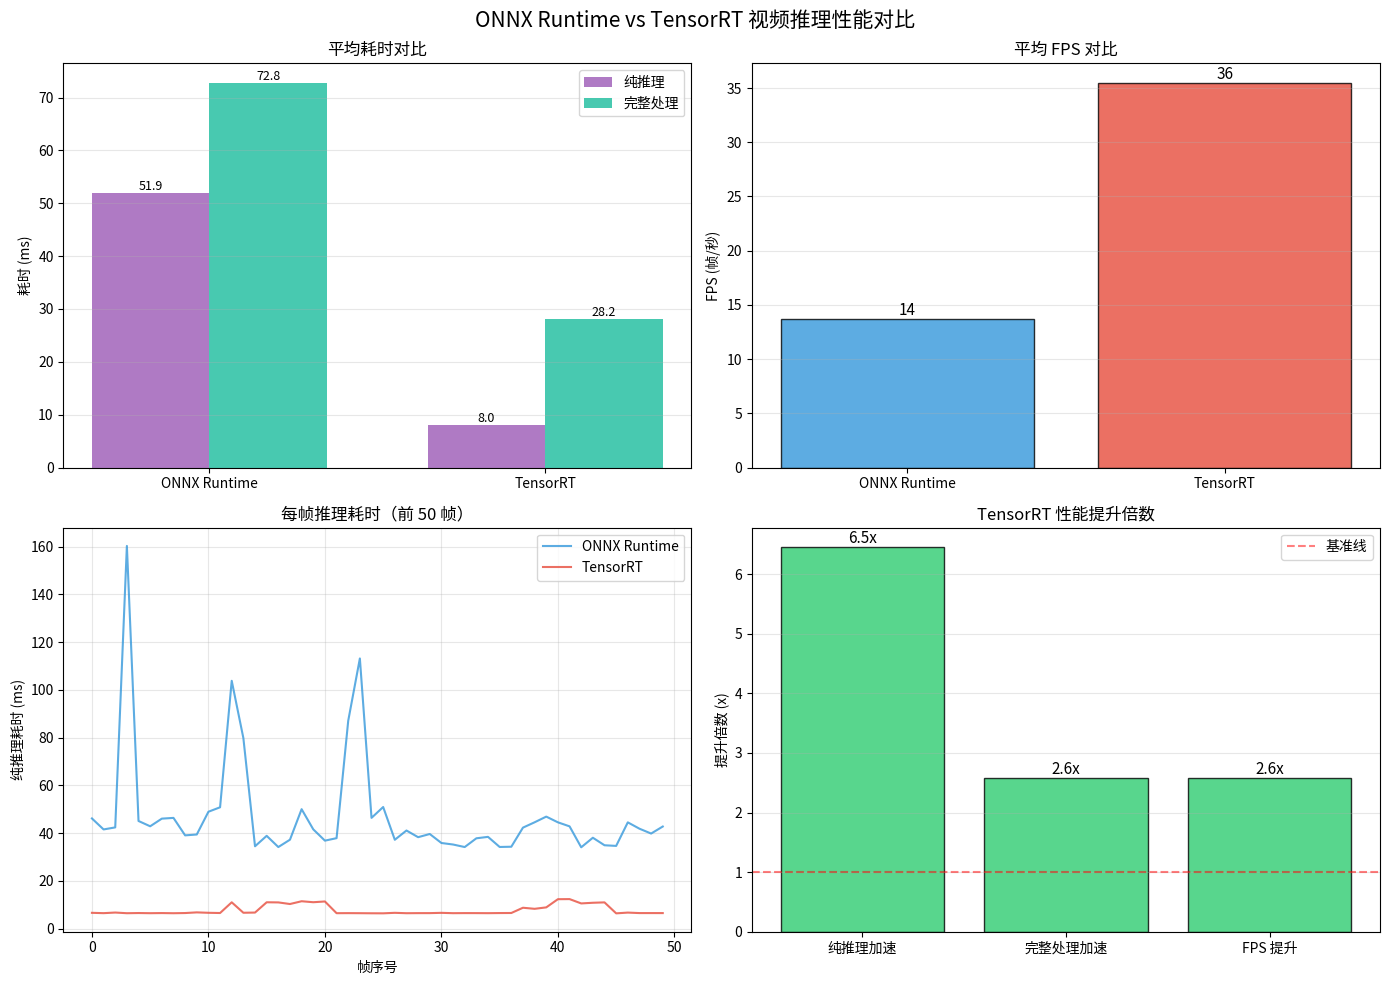

✅ 对比图表已保存: video_speed_comparison.png


In [21]:
# 配置中文字体（解决 matplotlib 中文乱码）
import matplotlib
from matplotlib import font_manager

cjk_font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
try:
    font_manager.fontManager.addfont(cjk_font_path)
    cjk_font = font_manager.FontProperties(fname=cjk_font_path).get_name()
    matplotlib.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
    matplotlib.rcParams['axes.unicode_minus'] = False   # 正常显示负号
    print(f"✅ 中文字体已加载: {cjk_font}")
except Exception as e:
    print(f"⚠️ 未找到中文字体，图表中文可能显示为方框: {e}")

# 可视化对比图表
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ONNX Runtime vs TensorRT 视频推理性能对比', fontsize=15, fontweight='bold')

colors = ['#3498db', '#e74c3c']
labels = ['ONNX Runtime', 'TensorRT']

# 1. 平均耗时对比（纯推理 + 完整处理）
ax1 = axes[0, 0]
x = np.arange(2)
width = 0.35
infer_data = [stats_onnx['infer_avg_ms'], stats_trt['infer_avg_ms']]
full_data = [stats_onnx['full_avg_ms'], stats_trt['full_avg_ms']]
bars1 = ax1.bar(x - width/2, infer_data, width, label='纯推理', color='#9b59b6', alpha=0.8)
bars2 = ax1.bar(x + width/2, full_data, width, label='完整处理', color='#1abc9c', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('耗时 (ms)')
ax1.set_title('平均耗时对比', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}', ha='center', va='bottom', fontsize=9)

# 2. FPS 对比
ax2 = axes[0, 1]
fps_data = [stats_onnx['avg_fps'], stats_trt['avg_fps']]
bars3 = ax2.bar(labels, fps_data, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('FPS (帧/秒)')
ax2.set_title('平均 FPS 对比', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, fps in zip(bars3, fps_data):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h, f'{fps:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. 每帧推理耗时折线图（稳定性）
ax3 = axes[1, 0]
n_plot = min(50, TEST_FRAMES)  # 只画前 50 帧便于观察
ax3.plot(range(n_plot), stats_onnx['infer_times_ms'][:n_plot], color=colors[0], alpha=0.8, label='ONNX Runtime')
ax3.plot(range(n_plot), stats_trt['infer_times_ms'][:n_plot], color=colors[1], alpha=0.8, label='TensorRT')
ax3.set_xlabel('帧序号')
ax3.set_ylabel('纯推理耗时 (ms)')
ax3.set_title(f'每帧推理耗时（前 {n_plot} 帧）', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. 性能提升倍数
ax4 = axes[1, 1]
metrics = ['纯推理加速', '完整处理加速', 'FPS 提升']
speedups = [
    stats_onnx['infer_avg_ms'] / stats_trt['infer_avg_ms'],
    stats_onnx['full_avg_ms'] / stats_trt['full_avg_ms'],
    stats_trt['avg_fps'] / stats_onnx['avg_fps'],
]
bars4 = ax4.bar(metrics, speedups, color='#2ecc71', alpha=0.8, edgecolor='black')
ax4.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='基准线')
ax4.set_ylabel('提升倍数 (x)')
ax4.set_title('TensorRT 性能提升倍数', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
for bar, sp in zip(bars4, speedups):
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h, f'{sp:.1f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('video_speed_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ 对比图表已保存: video_speed_comparison.png")

### 🎥 生成带标注的对比视频（可选）
分别用 ONNX Runtime 和 TensorRT 处理视频，输出带预测结果和实时 FPS 标注的视频文件，可直观对比两个后端的速度差异。
> ⏱️ 处理完整视频较慢，可设置 `OUTPUT_FRAMES` 限制帧数快速预览。

In [22]:
# 生成带标注的对比视频（复用 process_frame_onnx / process_frame_trt）
OUTPUT_FRAMES = 200   # 输出帧数（None = 全部视频，完整处理较慢）

def generate_annotated_video(input_path, process_func, backend_tag):
    """用指定处理函数逐帧处理视频，输出带标注的视频"""
    filehead = input_path.split('/')[-1]
    output_path = f"out-{backend_tag}-{filehead}"
    
    cap = cv2.VideoCapture(input_path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    max_n = OUTPUT_FRAMES if OUTPUT_FRAMES is not None else float('inf')
    n = 0
    with tqdm(total=int(max_n) if max_n != float('inf') else None, desc=f'{backend_tag}') as pbar:
        while cap.isOpened() and n < max_n:
            success, frame = cap.read()
            if not success:
                break
            try:
                frame = process_func(frame)
            except Exception as e:
                print(f'帧 {n} 报错: {e}')
            out.write(frame)
            n += 1
            pbar.update(1)
    
    out.release()
    cap.release()
    print(f'✅ [{backend_tag}] 已生成: {output_path}（{n} 帧）')
    return output_path

# 生成 ONNX Runtime 标注视频
print("🎬 生成 ONNX Runtime 标注视频...")
video_onnx = generate_annotated_video(VIDEO_PATH, process_frame_onnx, 'onnx')

# 生成 TensorRT 标注视频
print("\n🎬 生成 TensorRT 标注视频...")
video_trt = generate_annotated_video(VIDEO_PATH, process_frame_trt, 'trt')

print(f"\n🎉 对比视频生成完成！")
print(f"   ONNX Runtime: {video_onnx}")
print(f"   TensorRT:     {video_trt}")
print(f"💡 用播放器打开两个视频，观察左上角 FPS 数值的差异。")

🎬 生成 ONNX Runtime 标注视频...


onnx: 100%|██████████| 200/200 [00:19<00:00, 10.40it/s]


✅ [onnx] 已生成: out-onnx-video_4.mp4（200 帧）

🎬 生成 TensorRT 标注视频...


trt: 100%|██████████| 200/200 [00:10<00:00, 18.90it/s]

✅ [trt] 已生成: out-trt-video_4.mp4（200 帧）

🎉 对比视频生成完成！
   ONNX Runtime: out-onnx-video_4.mp4
   TensorRT:     out-trt-video_4.mp4
💡 用播放器打开两个视频，观察左上角 FPS 数值的差异。
